# Analyze Ising optimization results

This notebook reads the best optimization results from
`data/optimization_results/opt_Ising/` and plots the optimal squeezing parameter `xi`
as a function of the number of layers for different `Rb` and `Omega/Delta` values.

Expected directory structure:

```text
data/optimization_results/opt_Ising/
└── 4x4/
    ├── Rb_1p5/
    │   ├── OmegaDelta_1_2/
    │   │   ├── layers_1/
    │   │   ├── layers_2/
    │   │   └── ...
    │   ├── OmegaDelta_1_3/
    │   └── OmegaDelta_1_10/
    ├── Rb_2/
    └── Rb_2p5/
```

Each optimization JSON file is assumed to contain
`{"parameters": [...], "xi": ...}`.


In [526]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def dB(x):

    return 10 * np.log10(x)

## Locate the result directory

Run the notebook from the project root. If the notebook itself is stored elsewhere,
change `PROJECT_ROOT` below.


In [527]:
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "data" / "optimization_results" / "opt_Ising"

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Could not find results directory: {RESULTS_DIR}")


Project root: /Users/raka3858/PycharmProjects/PythonProject/VarOpt_MultiBody_Ising
Results directory: /Users/raka3858/PycharmProjects/PythonProject/VarOpt_MultiBody_Ising/data/optimization_results/opt_Ising


## Read all layer results

If more than one JSON file is present inside a layer directory, this keeps the file with
the smallest `xi`.


In [528]:
def parse_rb(name):
    # Rb_1p5 -> 1.5, Rb_2 -> 2.0
    value = name.removeprefix("Rb_").replace("p", ".")
    return float(value)


def parse_omega_delta(name):
    # OmegaDelta_1_2 -> numerator=1, denominator=2, ratio=0.5
    match = re.fullmatch(
        r"OmegaDelta_(\d+)_(\d+)",
        name,
    )

    if match is None:
        raise ValueError(
            f"Could not parse Omega/Delta folder name: {name}"
        )

    numerator = int(match.group(1))
    denominator = int(match.group(2))

    return (
        numerator,
        denominator,
        numerator / denominator,
    )


def parse_layer(name):
    match = re.fullmatch(
        r"layers_(\d+)",
        name,
    )

    if match is None:
        raise ValueError(
            f"Could not parse layer folder name: {name}"
        )

    return int(match.group(1))


def read_best_result(layer_dir):
    """
    Read the best optimization result from a layer directory.

    Preferred format:
        summary.npz

    Fallback format:
        older JSON optimization-result files

    Returns
    -------
    dict or None
        {
            "xi": float,
            "parameters": np.ndarray,
            "file": Path,
            "source": "summary" or "json",
        }
    """

    # --------------------------------------------------------
    # New format: summary.npz
    # --------------------------------------------------------

    summary_file = (
        layer_dir
        / "summary.npz"
    )

    if summary_file.exists():

        with np.load(
            summary_file
        ) as data:

            xi = float(
                data["best_fun"]
            )

            parameters = np.asarray(
                data["best_x"],
                dtype=float,
            )

        return {
            "xi": xi,
            "parameters": parameters,
            "file": summary_file,
            "source": "summary",
        }


    # --------------------------------------------------------
    # Old format: JSON files
    # --------------------------------------------------------

    json_files = [
        p
        for p in layer_dir.glob("*.json")
        if not p.name.endswith(".lock")
    ]

    if not json_files:
        return None

    records = []

    for path in json_files:

        with path.open(
            "r",
            encoding="utf-8",
        ) as f:

            data = json.load(f)

        if (
            "xi" not in data
            or "parameters" not in data
        ):
            continue

        records.append(
            (
                float(data["xi"]),
                np.asarray(
                    data["parameters"],
                    dtype=float,
                ),
                path,
            )
        )

    if not records:
        return None

    xi, parameters, path = min(
        records,
        key=lambda x: x[0],
    )

    return {
        "xi": xi,
        "parameters": parameters,
        "file": path,
        "source": "json",
    }


# ============================================================
# Read all optimization results
# ============================================================

rows = []

for geometry_dir in sorted(
    RESULTS_DIR.iterdir()
):

    if not geometry_dir.is_dir():
        continue

    geometry = geometry_dir.name

    for rb_dir in sorted(
        geometry_dir.glob("Rb_*")
    ):

        if not rb_dir.is_dir():
            continue

        rb = parse_rb(
            rb_dir.name
        )

        for omega_dir in sorted(
            rb_dir.glob("OmegaDelta_*")
        ):

            if not omega_dir.is_dir():
                continue

            (
                num,
                den,
                omega_over_delta,
            ) = parse_omega_delta(
                omega_dir.name
            )

            for layer_dir in sorted(
                omega_dir.glob("layers_*")
            ):

                if not layer_dir.is_dir():
                    continue

                n_layers = parse_layer(
                    layer_dir.name
                )

                best = read_best_result(
                    layer_dir
                )

                if best is None:
                    continue

                rows.append({
                    "geometry": geometry,
                    "Rb": rb,
                    "omega_num": num,
                    "omega_den": den,
                    "Omega_over_Delta": omega_over_delta,
                    "Omega_over_Delta_label": f"{num}/{den}",
                    "layers": n_layers,
                    "xi": best["xi"],
                    "parameters": best["parameters"],
                    "file": str(best["file"]),
                    "source": best["source"],
                })


# ============================================================
# Build dataframe
# ============================================================

df = pd.DataFrame(
    rows
)

if df.empty:
    raise RuntimeError(
        "No optimization results were found "
        "in the layer directories."
    )

df = (
    df
    .sort_values([
        "geometry",
        "Rb",
        "Omega_over_Delta",
        "layers",
    ])
    .reset_index(
        drop=True
    )
)

df

,geometry,Rb,omega_num,omega_den,Omega_over_Delta,Omega_over_Delta_label,layers,xi,parameters,file,source
0,4x4,1.5,1,10,0.1,1/10,1,0.617762,"[59514.4623639665, 8354.239821396619]",/Users/raka3858/PycharmProjects/PythonProject/...,summary
1,4x4,1.5,1,10,0.1,1/10,2,0.515159,"[56326.27912257209, 39664.39309715987, -2.5725...",/Users/raka3858/PycharmProjects/PythonProject/...,summary
2,4x4,1.5,1,10,0.1,1/10,3,0.457139,"[49171.60738446321, 37894.63576842382, 0.55069...",/Users/raka3858/PycharmProjects/PythonProject/...,summary
3,4x4,1.5,1,10,0.1,1/10,4,0.450545,"[34768.76700008132, 21604.101400791267, -2.822...",/Users/raka3858/PycharmProjects/PythonProject/...,summary
4,4x4,1.5,1,10,0.1,1/10,5,0.421943,"[32705.450175085116, 36567.60574823146, -2.768...",/Users/raka3858/PycharmProjects/PythonProject/...,summary
...,...,...,...,...,...,...,...,...,...,...,...
70,4x4,2.5,1,2,0.5,1/2,1,0.537932,"[140.65353139056603, 7.771400601006608]",/Users/raka3858/PycharmProjects/PythonProject/...,summary
71,4x4,2.5,1,2,0.5,1/2,2,0.488218,"[89.83424028434689, 25.42318885862656, 2.87753...",/Users/raka3858/PycharmProjects/PythonProject/...,summary
72,4x4,2.5,1,2,0.5,1/2,3,0.461558,"[126.43638443031857, 18.100805238778346, 1.773...",/Users/raka3858/PycharmProjects/PythonProject/...,summary
73,4x4,2.5,1,2,0.5,1/2,4,0.478152,"[35.692562413464756, 143.00348801544197, -1.79...",/Users/raka3858/PycharmProjects/PythonProject/...,summary


## Compact table of optimal values


In [529]:
display_cols = [
    "geometry",
    "Rb",
    "Omega_over_Delta_label",
    "layers",
    "xi",
]

df[display_cols]


,geometry,Rb,Omega_over_Delta_label,layers,xi
0,4x4,1.5,1/10,1,0.617762
1,4x4,1.5,1/10,2,0.515159
2,4x4,1.5,1/10,3,0.457139
3,4x4,1.5,1/10,4,0.450545
4,4x4,1.5,1/10,5,0.421943
...,...,...,...,...,...
70,4x4,2.5,1/2,1,0.537932
71,4x4,2.5,1/2,2,0.488218
72,4x4,2.5,1/2,3,0.461558
73,4x4,2.5,1/2,4,0.478152


## Plot 1: one figure per $R_b$, lines for different $\Omega/\Delta$


In [530]:
dB(1 / 9)

np.float64(-9.542425094393248)

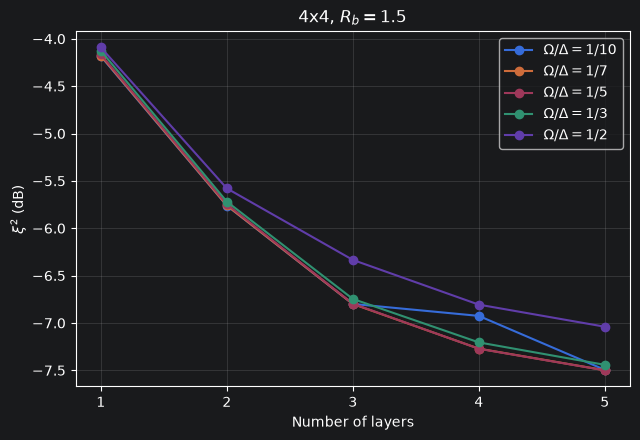

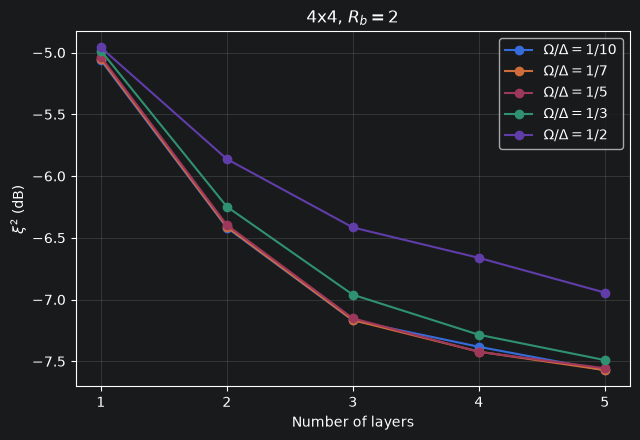

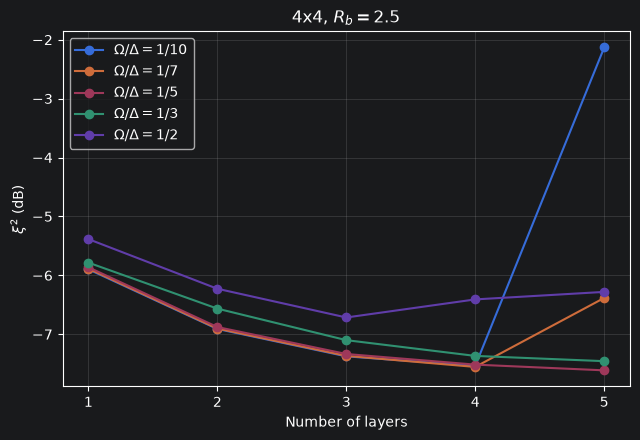

In [531]:
for geometry in sorted(df["geometry"].unique()):
    df_geom = df[df["geometry"] == geometry]

    for rb in sorted(df_geom["Rb"].unique()):
        fig, ax = plt.subplots(figsize=(6.5, 4.5))

        df_rb = df_geom[df_geom["Rb"] == rb]

        for label, group in df_rb.groupby("Omega_over_Delta_label", sort=False):
            group = group.sort_values("layers")
            ax.plot(
                group["layers"],
                dB(group["xi"] ** 2),
                marker="o",
                label=rf"$\Omega/\Delta={label}$",
            )

        ax.set_xlabel("Number of layers")
        ax.set_ylabel(r"$\xi^2\ $(dB)")
        ax.set_title(rf"{geometry}, $R_b={rb:g}$")
        ax.set_xticks(sorted(df_rb["layers"].unique()))
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()


## Plot 2: one figure per $\Omega/\Delta$, lines for different $R_b$


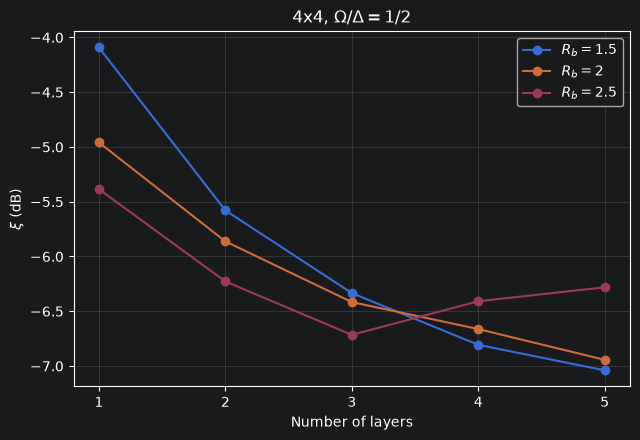

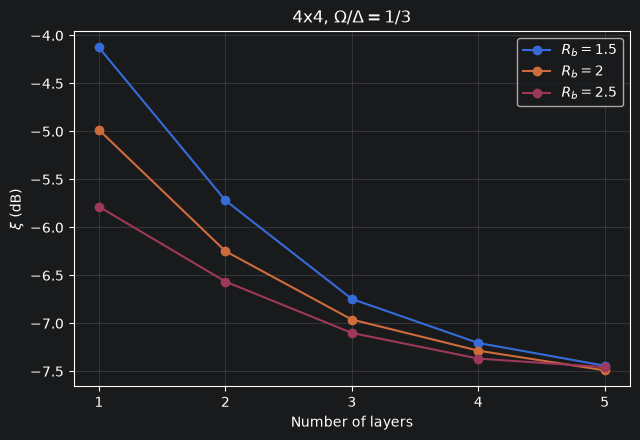

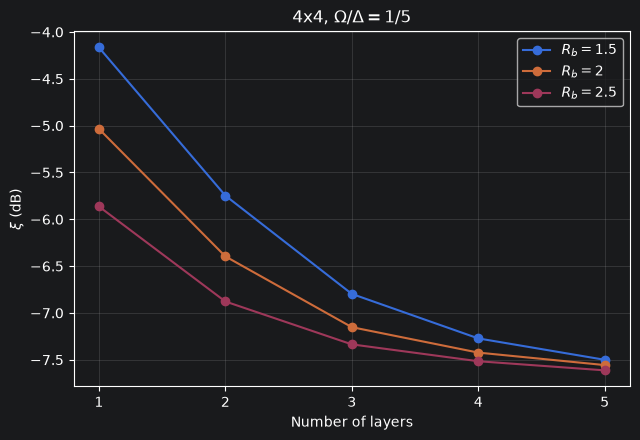

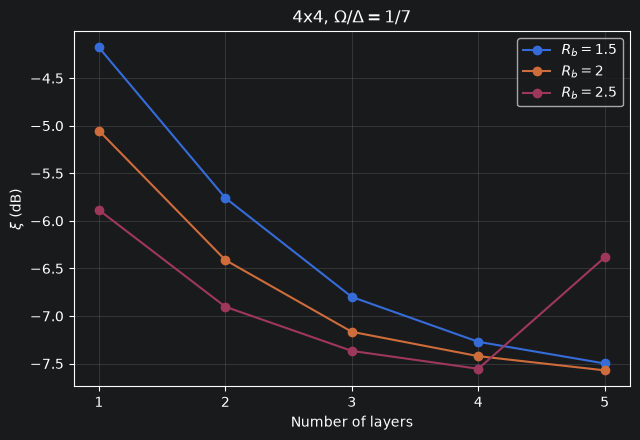

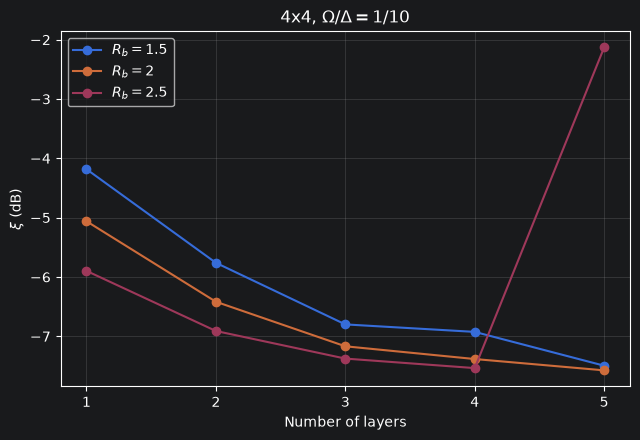

In [532]:
for geometry in sorted(df["geometry"].unique()):
    df_geom = df[df["geometry"] == geometry]

    labels = df_geom[["Omega_over_Delta", "Omega_over_Delta_label"]].drop_duplicates()
    labels = labels.sort_values("Omega_over_Delta", ascending=False)

    for _, row in labels.iterrows():
        ratio = row["Omega_over_Delta"]
        label = row["Omega_over_Delta_label"]

        fig, ax = plt.subplots(figsize=(6.5, 4.5))

        df_ratio = df_geom[np.isclose(df_geom["Omega_over_Delta"], ratio)]

        for rb, group in df_ratio.groupby("Rb"):
            group = group.sort_values("layers")
            ax.plot(
                group["layers"],
                dB(group["xi"] ** 2),
                marker="o",
                label=rf"$R_b={rb:g}$",
            )

        ax.set_xlabel("Number of layers")
        ax.set_ylabel(r"$\xi\ $(dB)")
        ax.set_title(rf"{geometry}, $\Omega/\Delta={label}$")
        ax.set_xticks(sorted(df_ratio["layers"].unique()))
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()


## Optional: show the optimized gate parameters

This is useful for inspecting the actual sequence parameters for a selected point.


In [533]:
dB(2 / (16 + 2))

np.float64(-9.542425094393248)

In [534]:
# Example selection
selection = df[
    (df["geometry"] == "4x4")
    & np.isclose(df["Rb"], 1.5)
    & np.isclose(df["Omega_over_Delta"], 0.5)
]

for _, row in selection.sort_values("layers").iterrows():
    print(
        f"layers={row['layers']:d}, "
        f"xi={row['xi']:.8g}, "
        f"parameters={row['parameters']}"
    )


layers=1, xi=0.6243265, parameters=[205.48716511  32.5050751 ]
layers=2, xi=0.52607229, parameters=[187.16404979 127.68219556   0.57033487 167.80989012  50.72018392]
layers=3, xi=0.48227171, parameters=[1.73116003e+02 9.03084601e+01 8.61773241e-01 1.79030662e+02
 1.24867854e+02 1.48673571e-01 1.41532872e+02 4.06625948e+01]
layers=4, xi=0.45675173, parameters=[184.12501193  75.18537009   1.19364249 216.01082153 183.62710835
  -1.38576265 101.20252986  25.19300877  -1.67721664 211.07536035
  36.82183774]
layers=5, xi=0.44465541, parameters=[ 1.25265026e+02  6.79978466e+01  9.12675068e-01  1.92110321e+02
  9.41053608e+01 -2.56914539e+00  1.56499682e+02  1.74787941e+02
 -1.51531866e+00  7.27824879e+01  2.94966772e-04  1.56271787e+00
  1.78117960e+02  3.29989300e+01]


## Optional: save the collected table


In [535]:
# Arrays in the 'parameters' column do not serialize cleanly to CSV, so store them as lists.
df_export = df.copy()
df_export["parameters"] = df_export["parameters"].apply(lambda x: x.tolist())

output_file = RESULTS_DIR / "optimization_summary.csv"
df_export.to_csv(output_file, index=False)
print("Saved:", output_file)


Saved: /Users/raka3858/PycharmProjects/PythonProject/VarOpt_MultiBody_Ising/data/optimization_results/opt_Ising/optimization_summary.csv
